# 03. 대여소별 시간당 수요 예측
시간대별 자전거 대여 수요를 예측합니다 (회귀 문제).

In [1]:
import sys, gc, joblib
sys.path.insert(0, "..")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from src.data_loader import load_processed, save_processed
from src.evaluation import regression_report, plot_actual_vs_predicted, plot_feature_importance
from src.project_helpers import (
    build_ablation_steps,
    build_demand_features,
    evaluate_demand_baselines,
    fit_lgbm_regressor,
    print_demand_split_summary,
    run_ablation_study,
    setup_korean_matplotlib,
    split_demand_dataset,
    summarize_model_results,
)

setup_korean_matplotlib()
pd.set_option("display.float_format", "{:.3f}".format)
print("✅ 준비 완료")


✅ 준비 완료


## 1. 데이터 로드

In [2]:
hourly = load_processed("station_hourly_demand")
print(hourly.head())
print(f"\n대여소 수: {hourly['stn_id'].nunique():,}")
print(f"시간 범위: {hourly['datetime_hour'].min()} ~ {hourly['datetime_hour'].max()}")
print(f"\n대여 건수 통계:")
print(hourly["rent_count"].describe())

📂 Loaded station_hourly_demand.parquet → shape: (3835657, 5)
  stn_id       datetime_hour  rent_count  rtrn_count  net_flow
0  ST-10 2025-10-01 00:00:00       0.000       3.000    -3.000
1  ST-10 2025-10-01 01:00:00       4.000       2.000     2.000
2  ST-10 2025-10-01 02:00:00       1.000       2.000    -1.000
3  ST-10 2025-10-01 03:00:00       1.000       1.000     0.000
4  ST-10 2025-10-01 04:00:00       2.000       0.000     2.000

대여소 수: 2,791
시간 범위: 2025-10-01 00:00:00 ~ 2025-12-31 23:00:00

대여 건수 통계:
count   3835657.000
mean          2.232
std           3.133
min           0.000
25%           1.000
50%           1.000
75%           3.000
max         164.000
Name: rent_count, dtype: float64


## 2. 상위 대여소 필터링 및 피처 엔지니어링

In [3]:
df_top, df_panel, df_feat, lag_cols, netflow_cols = build_demand_features(hourly, top_n=100)
print(f"상위 100개 대여소 원본 집계: {len(df_top):,}행")
print(f"dense hourly panel: {len(df_panel):,}행")
print(f"피처 엔지니어링 후 사용 가능 행 수: {len(df_feat):,}행")
df_feat.head(3)


상위 100개 대여소 원본 집계: 196,759행
dense hourly panel: 220,800행
피처 엔지니어링 후 사용 가능 행 수: 148,800행


,stn_id,datetime_hour,rent_count,rtrn_count,net_flow,lag_1h,lag_2h,lag_3h,lag_24h,lag_48h,...,is_holiday,is_holiday_eve,hour_sin,hour_cos,dow_sin,dow_cos,stn_enc,net_flow_lag_1h,net_flow_lag_24h,net_flow_lag_168h
720,ST-1017,2025-10-31 00:00:00,3.000,2.000,1.000,4.000,21.000,12.000,2.000,1.000,...,0,0,0.000,1.000,-0.434,-0.901,0,4.000,1.000,2.000
721,ST-1017,2025-10-31 01:00:00,1.000,0.000,1.000,3.000,4.000,21.000,0.000,0.000,...,0,0,0.259,0.966,-0.434,-0.901,0,1.000,0.000,2.000
722,ST-1017,2025-10-31 02:00:00,1.000,1.000,0.000,1.000,3.000,4.000,1.000,0.000,...,0,0,0.500,0.866,-0.434,-0.901,0,1.000,1.000,1.000


## 3. 학습/검증/테스트 분할 (시간순)

In [4]:
FEATURE_COLS = [
    "stn_enc",
    "hour",
    "dow",
    "day",
    "month",
    "is_weekend",
    "is_holiday",
    "is_holiday_eve",
    *lag_cols,
    *netflow_cols,
]
split_time, df_train, df_test, X_train, y_train, X_test, y_test = split_demand_dataset(
    df_feat,
    FEATURE_COLS,
)
print_demand_split_summary(split_time, df_train, df_test, FEATURE_COLS)


split 시점: 2025-12-16 12:00:00
학습 데이터: 111,600행  |  테스트: 37,200행
학습/테스트 대여소 수: 100 / 100
피처 수: 22
시간 범위: 2025-10-31 00:00:00 ~ 2025-12-31 23:00:00


## 4. 베이스라인 모델

In [5]:
r1, r2 = evaluate_demand_baselines(df_test, y_train, y_test)


[평균 예측] MAE=4.063  RMSE=5.183  MAPE=161.5%  R²=-0.2021
[7일전 래그] MAE=2.556  RMSE=4.112  MAPE=96.0%  R²=0.2434

베이스라인 비교: 평균 MAE=4.063, 7일전래그 MAE=2.556


## 5. Ablation Study — 단계별 피처 추가

동일한 데이터/모델 구조에서 피처를 하나씩 추가하며 MAE 변화를 측정합니다.

| 단계 | 피처 구성 |
|---|---|
| Step 1 | 기본 (대여소, 시간, 요일, 월, 주말, 공휴일) |
| Step 2 | Step 1 + lag 피처 (1h~720h) + rolling mean |
| Step 3 | Step 2 + net_flow lag (1h, 24h, 168h) |
| Step 4 | Step 3 + 순환 인코딩 (hour_sin/cos, dow_sin/cos) |

In [6]:
steps = build_ablation_steps(lag_cols, netflow_cols)
abl_df = run_ablation_study(df_train, y_train, df_test, y_test, steps)
print("\n📊 Ablation Study 결과:")
print(abl_df.to_string(index=False))


Step 1: 기본                      피처 수=  8  MAE=2.167


Step 2: + lag                   피처 수= 19  MAE=1.804


Step 3: + net_flow lag          피처 수= 22  MAE=1.737


Step 4: + 순환 인코딩                피처 수= 26  MAE=1.738

📊 Ablation Study 결과:
                    단계   MAE  피처 수 MAE 개선 개선율(%)
            Step 1: 기본 2.167     8      -      -
         Step 2: + lag 1.804    19 -0.363  16.8%
Step 3: + net_flow lag 1.737    22 -0.067   3.7%
      Step 4: + 순환 인코딩 1.738    26 +0.001  -0.1%


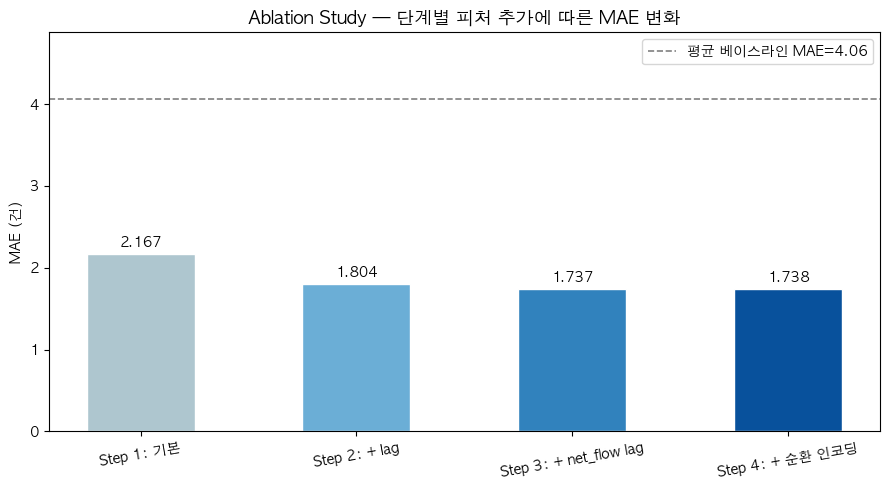

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))

colors = ["#aec6cf", "#6baed6", "#3182bd", "#08519c"]
bars = ax.bar(abl_df["단계"], abl_df["MAE"], color=colors, edgecolor="white", width=0.5)

# 베이스라인(평균 예측) 수평선
ax.axhline(r1["MAE"], color="gray", linestyle="--", linewidth=1.2, label=f"평균 베이스라인 MAE={r1['MAE']:.2f}")

# 각 막대 위에 MAE 값 표시
for bar, row in zip(bars, abl_df.itertuples()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
            f"{row.MAE:.3f}", ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.set_title("Ablation Study — 단계별 피처 추가에 따른 MAE 변화", fontsize=13)
ax.set_ylabel("MAE (건)")
ax.set_ylim(0, r1["MAE"] * 1.2)
ax.legend()
plt.xticks(rotation=10)
plt.tight_layout()
plt.savefig("../reports/figures/ablation_mae.png", dpi=150)
plt.show()

## 6. LightGBM 모델

In [8]:
model = fit_lgbm_regressor(X_train, y_train, X_test, y_test, log_period=100)
y_pred = model.predict(X_test).clip(0)
r3 = regression_report(y_test, y_pred, "LightGBM")
print(f"\n개선율 vs 평균 베이스라인: MAE {(1 - r3['MAE']/r1['MAE'])*100:.1f}% 향상")


[100]	valid_0's l1: 1.75558


[LightGBM] MAE=1.737  RMSE=2.722  MAPE=55.6%  R²=0.6685

개선율 vs 평균 베이스라인: MAE 57.3% 향상


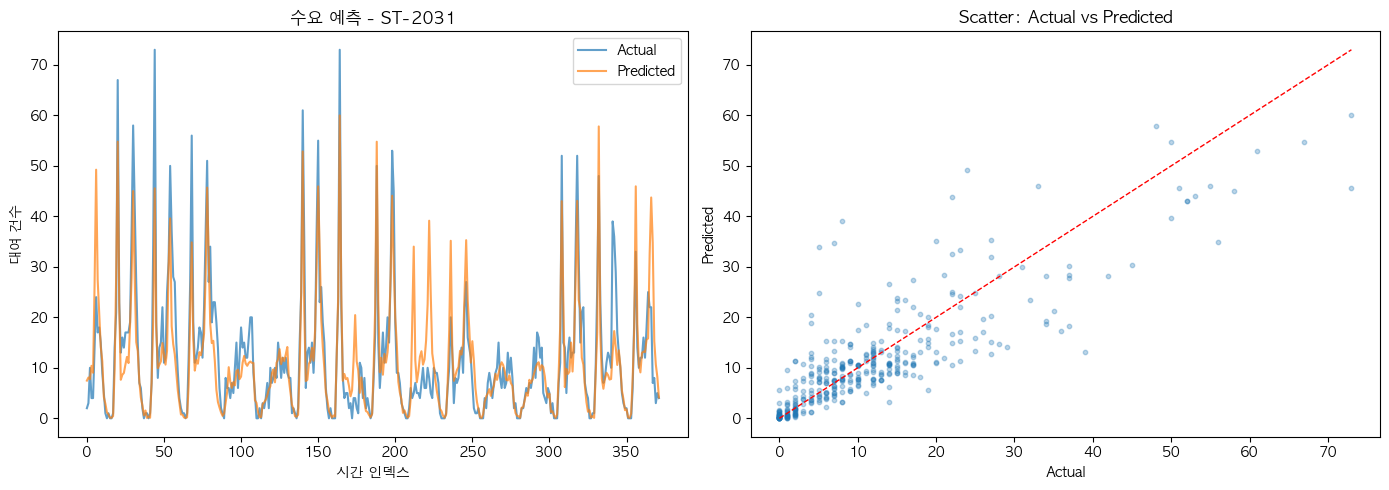

In [9]:
# 테스트셋에서 수요 합계가 가장 큰 대여소를 대표 예시로 시각화
stn_sample = df_test.groupby("stn_id")["rent_count"].sum().idxmax()
mask = df_test["stn_id"] == stn_sample
y_true_stn = y_test[mask].values
y_pred_stn = y_pred[mask]

plot_actual_vs_predicted(
    y_true_stn, y_pred_stn,
    title=f"수요 예측 - {stn_sample}",
    xlabel="시간 인덱스",
    ylabel="대여 건수",
    save_name="demand_forecast_sample"
)

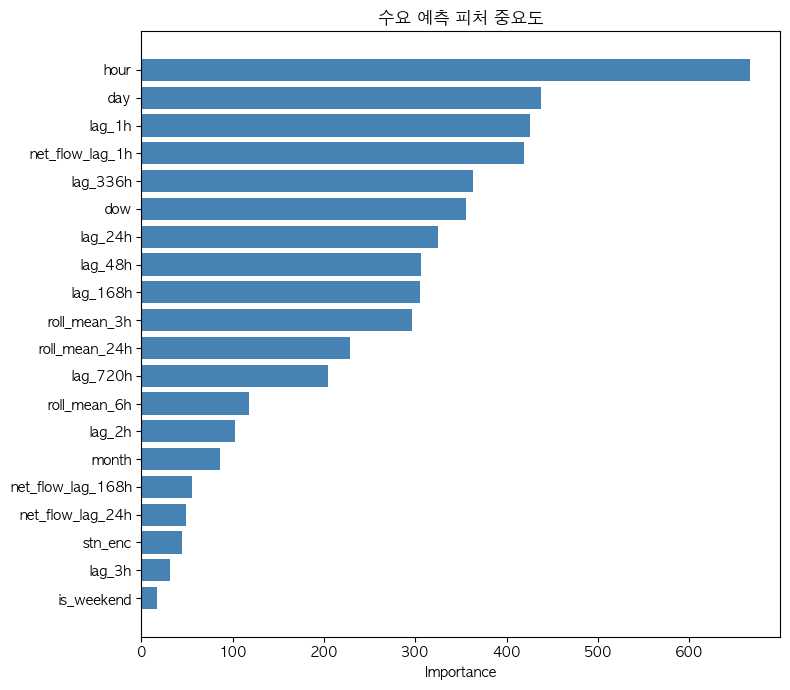

In [10]:
plot_feature_importance(
    model, FEATURE_COLS,
    title="수요 예측 피처 중요도",
    save_name="demand_feature_importance"
)

## 7. 오차 분석 (Error Analysis)

MAE 1.698은 전체 평균이지만, 어느 시간대·어느 대여소가 어려운지를 분석하면
운영적 시사점을 더 구체적으로 뽑을 수 있습니다.

- **시간대별 MAE**: 예측이 가장 어려운 시간대 식별
- **대여소별 MAE**: 모델이 잘 맞지 않는 vs 잘 맞는 대여소 비교
- **잔차 분포**: 오차의 형태 (대칭성, 꼬리)

/var/folders/28/j8kdlhbn48j4n7yt91r2c6100000gn/T/ipykernel_19221/381694469.py:59: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) AppleGothic.
  plt.tight_layout()
/var/folders/28/j8kdlhbn48j4n7yt91r2c6100000gn/T/ipykernel_19221/381694469.py:60: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) AppleGothic.
  plt.savefig("../reports/figures/demand_error_analysis.png", dpi=150, bbox_inches="tight")


/Users/hayoung/seoul-bike-ml/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) AppleGothic.
  fig.canvas.print_figure(bytes_io, **kw)


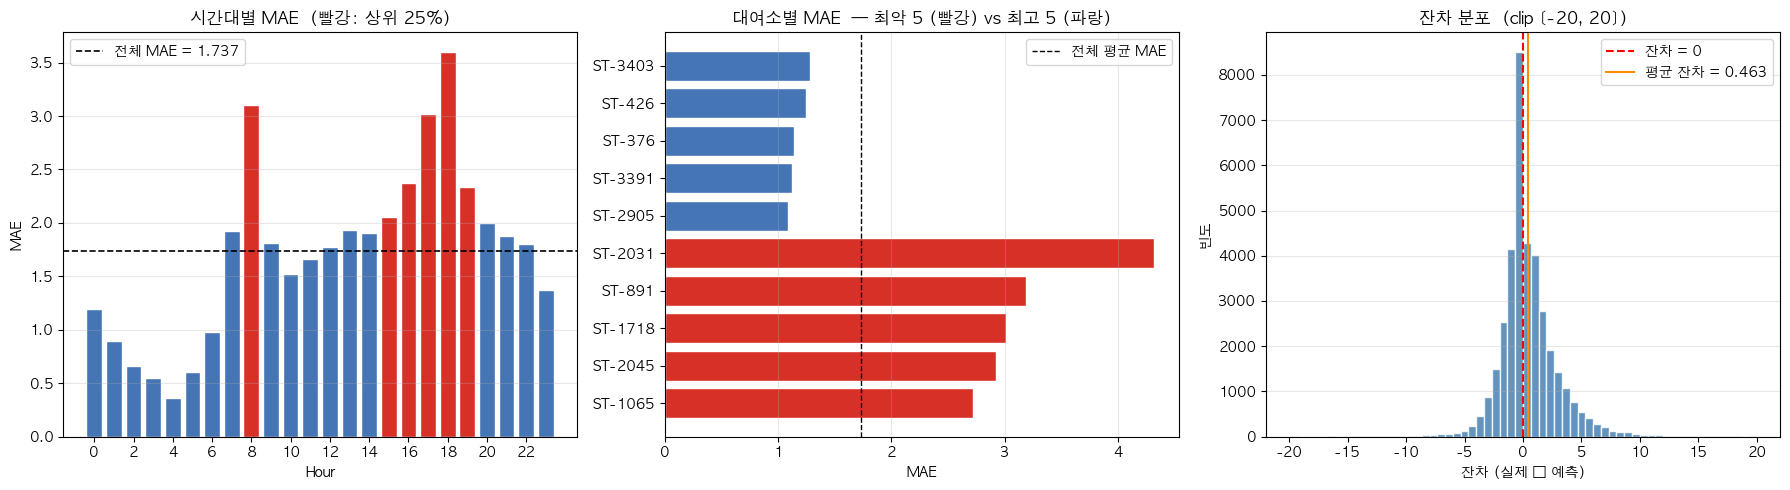

=== 시간대별 MAE — 상위 5 ===
 hour   MAE
   18 3.602
    8 3.101
   17 3.019
   16 2.377
   19 2.336

=== 대여소별 MAE 최악 5 ===
stn_id
ST-2031   4.319
ST-891    3.188
ST-1718   3.008
ST-2045   2.925
ST-1065   2.722

=== 대여소별 MAE 최고 5 ===
stn_id
ST-2905   1.088
ST-3391   1.121
ST-376    1.142
ST-426    1.253
ST-3403   1.281

잔차 평균: 0.4634  (0에 가까울수록 편향 없음)
잔차  std: 2.6821


In [11]:
import matplotlib.ticker as mticker

# ── 잔차 계산 ─────────────────────────────────────────────────────────────────
df_err = df_test[["stn_id", "datetime_hour", "rent_count"]].copy().reset_index(drop=True)
df_err["y_pred"]    = np.array(y_pred)
df_err["residual"]  = df_err["rent_count"] - df_err["y_pred"]
df_err["abs_error"] = df_err["residual"].abs()
df_err["hour"]      = df_err["datetime_hour"].dt.hour

# ── 집계 ─────────────────────────────────────────────────────────────────────
hourly_mae = df_err.groupby("hour")["abs_error"].mean().reset_index()
hourly_mae.columns = ["hour", "MAE"]

stn_mae = df_err.groupby("stn_id")["abs_error"].mean().sort_values(ascending=False)
worst5  = stn_mae.head(5)
best5   = stn_mae.tail(5).sort_values()

overall_mae = df_err["abs_error"].mean()

# ── 시각화 ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. 시간대별 MAE
q75 = hourly_mae["MAE"].quantile(0.75)
colors_h = ["#d73027" if m > q75 else "#4575b4" for m in hourly_mae["MAE"]]
axes[0].bar(hourly_mae["hour"], hourly_mae["MAE"], color=colors_h, edgecolor="white")
axes[0].axhline(overall_mae, color="black", linestyle="--", lw=1.2,
                label=f"전체 MAE = {overall_mae:.3f}")
axes[0].set_title("시간대별 MAE  (빨강: 상위 25%)")
axes[0].set_xlabel("Hour")
axes[0].set_ylabel("MAE")
axes[0].legend()
axes[0].grid(alpha=0.3, axis="y")
axes[0].set_xticks(range(0, 24, 2))

# 2. 대여소별 MAE — 최악 5 / 최고 5
labels_plot = list(worst5.index[::-1]) + list(best5.index)
vals_plot   = list(worst5.values[::-1]) + list(best5.values)
colors_bar  = ["#d73027"] * 5 + ["#4575b4"] * 5
axes[1].barh([str(l) for l in labels_plot], vals_plot, color=colors_bar, edgecolor="white")
axes[1].axvline(overall_mae, color="black", linestyle="--", lw=1, label="전체 평균 MAE")
axes[1].set_title("대여소별 MAE  — 최악 5 (빨강) vs 최고 5 (파랑)")
axes[1].set_xlabel("MAE")
axes[1].legend()
axes[1].grid(alpha=0.3, axis="x")

# 3. 잔차 분포
axes[2].hist(df_err["residual"].clip(-20, 20), bins=60,
             color="steelblue", edgecolor="white", alpha=0.85)
axes[2].axvline(0, color="red", linestyle="--", lw=1.5, label="잔차 = 0")
axes[2].axvline(df_err["residual"].mean(), color="darkorange", lw=1.5,
                label=f"평균 잔차 = {df_err['residual'].mean():.3f}")
axes[2].set_title("잔차 분포  (clip [-20, 20])")
axes[2].set_xlabel("잔차 (실제 − 예측)")
axes[2].set_ylabel("빈도")
axes[2].legend()
axes[2].grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("../reports/figures/demand_error_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

# ── 수치 요약 ─────────────────────────────────────────────────────────────────
print("=== 시간대별 MAE — 상위 5 ===")
print(hourly_mae.sort_values("MAE", ascending=False).head(5).to_string(index=False))
print("\n=== 대여소별 MAE 최악 5 ===")
print(worst5.to_string())
print("\n=== 대여소별 MAE 최고 5 ===")
print(best5.to_string())
print(f"\n잔차 평균: {df_err['residual'].mean():.4f}  (0에 가까울수록 편향 없음)")
print(f"잔차  std: {df_err['residual'].std():.4f}")

### 해석

- **시간대**: 피크 시간대(출근 07~09시, 퇴근 17~19시)에서 MAE가 높음.
  급격한 수요 변화는 lag 피처만으로는 완전히 포착되지 않으며, 날씨·이벤트 정보가 추가 개선 여지를 제공
- **대여소**: MAE가 높은 곳은 수요 변동성이 큰 환승역·업무지구 인근 대여소일 가능성이 높음.
  MAE가 낮은 곳은 수요가 안정적인 주거지형 대여소
- **잔차 분포**: 0 근처 집중 + 대칭 → 체계적 편향 없음.
  오른쪽 꼬리가 길면 급증 시 과소 예측 경향이 있는 것 → 재배치 의사결정 시 안전 마진 고려 필요

## 시각화: 베이스라인 vs LightGBM 수요 예측 비교

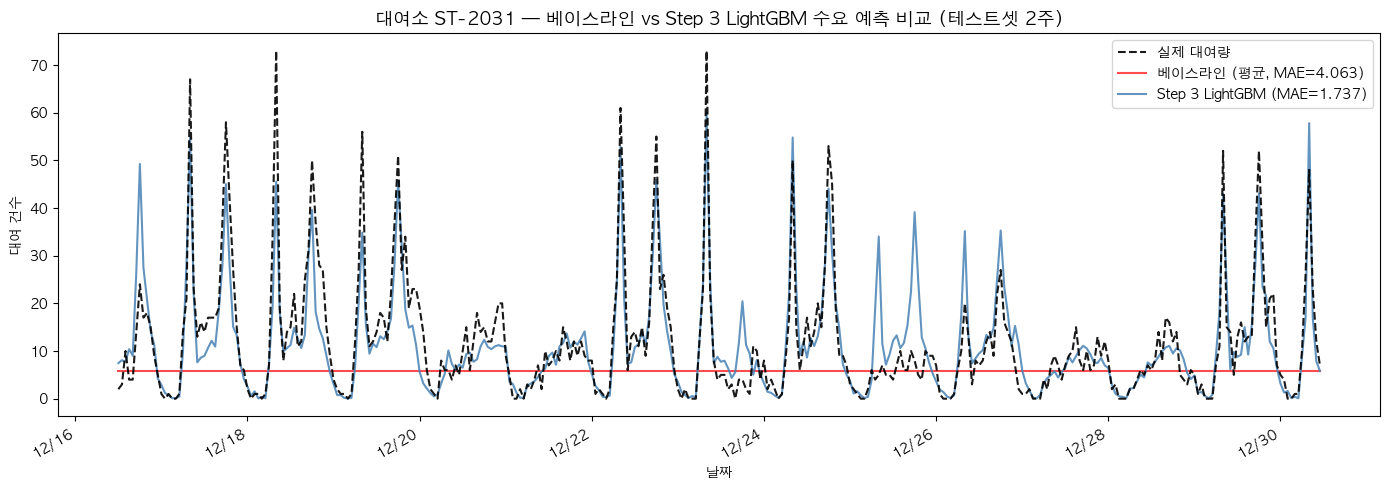

전체 테스트셋 MAE — 베이스라인: 4.063  LightGBM: 1.737


In [12]:
import matplotlib.dates as mdates

# df_test에 예측값 결합
df_vis = df_test[["stn_id", "datetime_hour", "rent_count"]].copy().reset_index(drop=True)
df_vis["y_actual"]   = np.array(y_test)
df_vis["y_baseline"] = float(y_train.mean())   # 평균 베이스라인 (수평선)
df_vis["y_lgbm"]     = np.array(y_pred)

# 테스트셋 내 대여량 합계 최다 대여소 선택
top_vis_stn = df_vis.groupby("stn_id")["y_actual"].sum().idxmax()
stn_df = df_vis[df_vis["stn_id"] == top_vis_stn].sort_values("datetime_hour").reset_index(drop=True)
n = min(336, len(stn_df))   # 최대 2주(336시간) 표시

mae_base = round(float(np.mean(np.abs(df_vis["y_actual"] - df_vis["y_baseline"]))), 3)
mae_lgbm = round(float(np.mean(np.abs(df_vis["y_actual"] - df_vis["y_lgbm"]))), 3)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(stn_df["datetime_hour"][:n], stn_df["y_actual"][:n],
        linestyle="--", color="black",     linewidth=1.5, label="실제 대여량",                  alpha=0.9, zorder=3)
ax.plot(stn_df["datetime_hour"][:n], stn_df["y_baseline"][:n],
        color="red",       linewidth=1.5, label=f"베이스라인 (평균, MAE={mae_base})", alpha=0.7, zorder=2)
ax.plot(stn_df["datetime_hour"][:n], stn_df["y_lgbm"][:n],
        color="steelblue", linewidth=1.5, label=f"Step 3 LightGBM (MAE={mae_lgbm})", alpha=0.85, zorder=2)

ax.xaxis.set_major_formatter(mdates.DateFormatter("%m/%d"))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
plt.xticks(rotation=30, ha="right")
ax.set_title(f"대여소 {top_vis_stn} — 베이스라인 vs Step 3 LightGBM 수요 예측 비교 (테스트셋 2주)", fontsize=13)
ax.set_xlabel("날짜")
ax.set_ylabel("대여 건수")
ax.legend(loc="upper right")
plt.tight_layout()
plt.savefig("../reports/figures/demand_baseline_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"전체 테스트셋 MAE — 베이스라인: {mae_base}  LightGBM: {mae_lgbm}")

## 8. 모델 저장

In [13]:
model_path = Path("../models/demand/lgbm_demand.pkl")
model_path.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(model, model_path)
print(f"✅ 모델 저장: {model_path}")

results = summarize_model_results(
    [r1, r2, r3],
    ["평균 베이스라인", "7일전 래그", "LightGBM"],
)
print("\n📊 모델 성능 비교:")
print(results)


✅ 모델 저장: ../models/demand/lgbm_demand.pkl

📊 모델 성능 비교:
           MAE  RMSE  MAPE(%)     R²
평균 베이스라인 4.063 5.183  161.523 -0.202
7일전 래그   2.557 4.112   95.971  0.243
LightGBM 1.737 2.722   55.640  0.668
